<h1 style="text-align: center;">SMT Challenge 2025 Bayesian Analysis</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to conduct the Bayesian Analysis of the data + the quantification of Aggressiveness</h3>

### Necessary Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

### Helper Functions

In [23]:
def visual_trajectory(df: pd.DataFrame, game_str_id: str) -> None:
    """
    Displays the trajectory of any given play from the point of contact to the point the ball is acquired

    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    df = df.iloc[df[df['event_code'] == 4].index[0]:df[df['event_code'] == 2].index[0]+1, :].reset_index(drop=True).copy()

    xyz_ball = df[['ball_position_y', 'ball_position_z']].reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(xyz_ball['ball_position_y'], xyz_ball['ball_position_z'])
    ax.set_xlabel('ball position y')
    ax.set_xlim(0, 400)
    ax.set_ylabel('ball position z')
    ax.set_ylim(0, 45)
    ax.set_title(f'Visualization of Ball Trajectory: {game_str_id}')
    plt.show()

In [5]:
def attempt_metric_creator(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    """
    Creates the column of a metric in df that has multiple columns for each fielder
    Bases it on who made the attempt (which has been talked about how that works) 
    
    Arguments: df: Dataframe, col_name: some metric with columns for each fielder
    """
    df = df.copy()
    df.loc[:, col_name] = np.where(df['player_attempt'] == 7, 
                                           df[f'{col_name}_7'],
                                           np.where(
                                               df['player_attempt'] == 8, 
                                               df[f'{col_name}_8'], 
                                               np.where(
                                                   df['player_attempt'] == 9, 
                                                   df[f'{col_name}_9'],
                                                   np.nan)))
    return df

In [6]:
def info_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Displays information about the dataframe with # of missing values, unique numbers, datatypes, etc.
    
    Arguments: Dataframe
    """
    df = df.copy()
    dtype = df.dtypes
    num_unique = df.T.apply(lambda x: x.nunique(), axis=1)
    nan_total = df.isnull().sum()
    nan_percent = (df.isnull().sum()/df.isnull().count()*100)
    quality_df = pd.concat([nan_total, nan_percent, num_unique, dtype], axis=1, keys=['total_NaNs', 'NaN%', 'num_unique', 'dtypes'])
    display(quality_df)

In [7]:
def metric_into_dict(df: pd.DataFrame, metric) -> dict:
    """
    Creates a dictionary of a metric for each unique play
    
    Arguments: df: Dataframe, metric: one of the helper functions used to calculate some feature
    """
    df = df.copy()
    
    empty_dict = {}
    for i in list(df['game_str_id'].unique()):
        try:
            empty_dict[i] = metric(df, i)
        except Exception as e:
            ## this is a list of plays that cause errors
            print(f"Error play: {i} | Exception: {e}")
            # if i not in messy_plays:
            #     messy_plays.append(i)
            continue
    return empty_dict

In [8]:
def euclidean_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """
    Takes the euclidean distance between two points

    Arguments: (x1, y1), (x2, y2)
    """
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)

In [9]:
def delta_velo_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
    """
    Calculates the change in velocity for each position

    Arguments: df: Dataframe, position: either 7, 8, or 9
    """
    df = df.copy()
    df[f'delta_velo_{position}'] = np.where(df['timestamp'] > df['timestamp'].shift(1), 
                                            df[f'instantaneous_velo_{position}'] - df[f'instantaneous_velo_{position}'].shift(1), 
                                            np.nan)
    return df

In [ ]:
    def stepwise_dist_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
        """
        Calculates the stepwise distance for each position

        Arguments: df: Dataframe, position: either 7, 8, or 9
        """
        df = df.copy()
        df.loc[:, f'stepwise_dist_{position}'] = (
            np.where(df['timestamp'] > df['timestamp'].shift(1), 
                        euclidean_distance(df[f'field_x_{position}'], df[f'field_y_{position}'], 
                                        df[f'field_x_{position}'].shift(1), df[f'field_y_{position}'].shift(1)
                                        ), 
                        np.nan))
        return df

### Loading in the Data

In [11]:
play_data_w_catch_probs = pd.read_csv('catch_probabilities.csv').iloc[:, 1:].copy()
aggressive_data = pd.read_csv('aggressive_data.csv', low_memory=False).iloc[:, 1:].copy()

### Quantifying the Aggressive Binary Target

In [11]:
# play_by_play.loc[:, 'p_catch'] = play_by_play['p_catch'].apply(lambda x: x*100)
# reaction_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['reaction'].mean().to_dict()
# burst_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['burst'].mean().to_dict()
# route_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['route'].mean().to_dict()
# play_by_play.loc[:, 'avg_reaction'] = play_by_play.apply(lambda x: reaction_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'avg_burst'] = play_by_play.apply(lambda x: burst_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'avg_route'] = play_by_play.apply(lambda x: route_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'reaction_vs_avg'] = play_by_play['reaction'] - play_by_play['avg_reaction']
# play_by_play.loc[:, 'burst_vs_avg'] = play_by_play['burst'] - play_by_play['avg_burst']
# play_by_play.loc[:, 'route_vs_avg'] = play_by_play['route'] - play_by_play['avg_route']
# play_by_play.loc[:, 'feet_vs_avg'] = play_by_play['reaction_vs_avg'] + play_by_play['burst_vs_avg'] + play_by_play['route_vs_avg']

In [21]:
def catch_point_speed(df: pd.DataFrame, game_str_id: str) -> np.array:
    """
    Finds the speed of the player who made the attempt 0.5 sec before and after the catch
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff']#.iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff']#.iloc[2:]

    time_contact = df.loc[df['event_code'] == 4]['elapsed_timestamp'].iloc[0]
    burst_idx = abs(df.loc[round(df['elapsed_timestamp'], 1) == 1.5]['elapsed_timestamp'] - 1.5).idxmin()
    burst_marker = df.loc[burst_idx]['elapsed_timestamp']
    catch_point = df.loc[(df['event_code'] == 2) & (df['player_position'].isin([7, 8, 9]))]['elapsed_timestamp'].iloc[0]
    
    one_half_sec_before_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point-1.5, 1)]['elapsed_timestamp'] - round(catch_point-1.5, 1)).idxmin()
    if round(catch_point+0.5, 1) > df['elapsed_timestamp'].iloc[-1]:
        one_half_sec_after_catch = df.shape[0]+1
        end_time = 1.5 + (df['elapsed_timestamp'].iloc[-1] - catch_point)
    else:
        one_half_sec_after_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point+0.5, 1)]['elapsed_timestamp'] - round(catch_point+0.5, 1)).idxmin() + 1
        end_time = 2
    df = df.iloc[one_half_sec_before_catch: one_half_sec_after_catch].reset_index(drop=True).copy()

    lf_catch_speed = df[f'stepwise_dist_7'].sum() / end_time
    cf_catch_speed = df[f'stepwise_dist_8'].sum() / end_time
    rf_catch_speed = df[f'stepwise_dist_9'].sum() / end_time

    print([lf_catch_speed, cf_catch_speed, rf_catch_speed])

    return df#np.array([lf_catch_speed, cf_catch_speed, rf_catch_speed])

In [ ]:
catch_point_speed(aggressive_data, 'y2_d067_HKR_RZQ_111')

In [28]:
def visual_trajectory(df: pd.DataFrame, game_str_id: str) -> None:
    """
    Displays the trajectory of any given play from the point of contact to the point the ball is acquired

    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    # df = df.iloc[df[df['event_code'] == 4].index[0]:df[df['event_code'] == 2].index[0]+1, :].reset_index(drop=True).copy()

    return df

    # xyz_ball = df[['ball_position_y', 'ball_position_z']].reset_index(drop=True)
    # fig, ax = plt.subplots(figsize=(6, 6))
    # ax.plot(xyz_ball['ball_position_y'], xyz_ball['ball_position_z'])
    # ax.set_xlabel('ball position y')
    # ax.set_xlim(0, 400)
    # ax.set_ylabel('ball position z')
    # ax.set_ylim(0, 45)
    # ax.set_title(f'Visualization of Ball Trajectory: {game_str_id}')
    # plt.show()

In [29]:
visual_trajectory(aggressive_data, 'y2_d067_HKR_RZQ_111')

,game_str_id,timestamp,at_bat,play_per_game,player_position,player_position_name,event_code,event_code_name,field_x_7,field_y_7,field_x_8,field_y_8,field_x_9,field_y_9,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,timestamp_diff,elapsed_timestamp
0,y2_d067_HKR_RZQ_111,3833.615,31,104.0,1.0,pitcher,1.0,pitch,-127.1490,232.7640,-34.1784,307.7910,114.4446,255.1560,-2.306724,52.06470,6.245550,RZQ,HKR,year_2,day_067,0.00,0.00
1,y2_d067_HKR_RZQ_111,3833.665,NaN,NaN,NaN,NaN,NaN,NaN,-127.1790,232.6485,-34.1916,308.0085,114.3654,254.8395,-1.932696,45.98400,5.940510,NaN,NaN,NaN,NaN,0.05,0.05
2,y2_d067_HKR_RZQ_111,3833.715,NaN,NaN,NaN,NaN,NaN,NaN,-127.2078,232.5405,-34.2051,308.2263,114.2703,254.3898,-1.590816,39.95490,5.584890,NaN,NaN,NaN,NaN,0.05,0.10
3,y2_d067_HKR_RZQ_111,3833.765,NaN,NaN,NaN,NaN,NaN,NaN,-127.2342,232.4418,-34.2183,308.4438,114.1929,254.0007,-1.281090,33.97710,5.178600,NaN,NaN,NaN,NaN,0.05,0.15
4,y2_d067_HKR_RZQ_111,3833.815,NaN,NaN,NaN,NaN,NaN,NaN,-127.2570,232.3542,-34.2318,308.6616,114.1179,254.1051,-1.003512,28.05087,4.721670,NaN,NaN,NaN,NaN,0.05,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,y2_d067_HKR_RZQ_111,3838.565,31,104.0,8.0,center field,2.0,ball acquired,-98.2917,269.0376,-39.2241,382.2432,94.2210,283.8630,-31.793100,390.24900,-0.517491,RZQ,HKR,year_2,day_067,0.05,4.95
100,y2_d067_HKR_RZQ_111,3838.615,NaN,NaN,NaN,NaN,NaN,NaN,-97.8600,269.5716,-39.0549,383.5482,94.0344,284.3487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,5.00
101,y2_d067_HKR_RZQ_111,3838.665,NaN,NaN,NaN,NaN,NaN,NaN,-97.4274,270.1053,-38.8137,385.0311,93.8487,284.8350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,5.05
102,y2_d067_HKR_RZQ_111,3838.715,NaN,NaN,NaN,NaN,NaN,NaN,-96.9948,270.6390,-38.2560,385.4862,93.6639,285.3225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,5.10


In [221]:
def plot_velo_acc(df: pd.DataFrame, game_str_id: str, position: int) -> None:
    """
    Finds the speed of the player who made the attempt 0.5 sec before and after the catch
    
    Arguments: df: Dataframe, game_str_id: game_str_id, position: outfielder code (7, 8, or 9)
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff'].iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff'].iloc[2:]

    time_contact = df.loc[df['event_code'] == 4]['elapsed_timestamp'].iloc[0]
    catch_point = df.loc[(df['event_code'] == 2) & (df['player_position'].isin([7, 8, 9]))]['elapsed_timestamp'].iloc[0]
    one_half_sec_before_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point-1.5, 1)]['elapsed_timestamp'] - round(catch_point-1.5, 1)).idxmin()
    one_half_s_marker = df.loc[one_half_sec_before_catch]['elapsed_timestamp']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    sns.lineplot(data=df.iloc[1:], x='elapsed_timestamp', y=f'instantaneous_velo_{position}', ax=ax1)
    ax1.axvline(x=time_contact, label='time of contact', c='red')
    ax1.axvline(x=one_half_s_marker, label='1.5 sec before catch', c='black')
    ax1.axvline(x=catch_point, label='catch point', c='green')
    ax1.set_title(f"{position}'s Velocity in Play {game_str_id}")
    sns.lineplot(data=df.iloc[2:], x='elapsed_timestamp', y=f'instantaneous_acc_{position}', ax=ax2)
    ax2.axvline(x=time_contact, label='time of contact', c='red')
    ax2.axvline(x=one_half_s_marker, label='1.5 sec before catch', c='black')
    ax2.axvline(x=catch_point, label='catch point', c='green')
    ax2.set_title(f"{position}'s Acceleration in Play {game_str_id}")
    plt.legend()
    plt.tight_layout()
    plt.show()

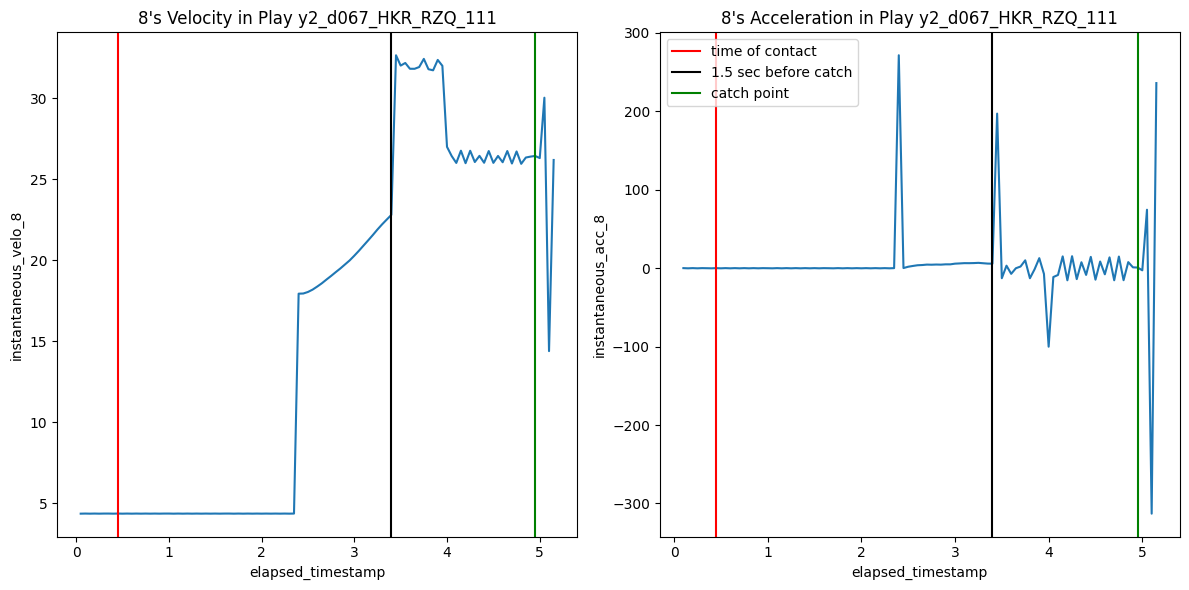

In [222]:
plot_velo_acc(aggressive_data, 'y2_d067_HKR_RZQ_111', 8)

In [ ]:
catch_point_speed_dict = metric_into_dict(aggressive_data, catch_point_speed)
catch_point_speed_df = pd.DataFrame.from_dict(catch_point_speed_dict, orient='index', columns=['catch_speed_7', 'catch_speed_8', 'catch_speed_9']).reset_index(names=['game_str_id']).copy()

In [195]:
play_data_w_catch_probs = play_data_w_catch_probs.merge(catch_point_speed_df, on='game_str_id', how='left').copy()

In [201]:
catch_speeds = play_data_w_catch_probs[['catch_speed_7', 'catch_speed_8', 'catch_speed_9']]
sprint_speeds = play_data_w_catch_probs[['sprint_speed_7', 'sprint_speed_8', 'sprint_speed_9']].map(lambda x: np.nan if round(x) == 0 else x)
play_data_w_catch_probs[['catch_speed_ratio_7', 'catch_speed_ratio_8', 'catch_speed_ratio_9']] = catch_speeds.values / sprint_speeds.values

In [205]:
play_data_w_catch_probs = attempt_metric_creator(play_data_w_catch_probs, 'catch_speed_ratio').copy()

In [210]:
play_data_w_catch_probs[(play_data_w_catch_probs['difficulty_level'] == '5 Star') 
                        & ((play_data_w_catch_probs['is_out_catch'] == 1) | (play_data_w_catch_probs['whiffed_catch'] == 1))
                        & (play_data_w_catch_probs['catch_speed_ratio']>=1)
                        ].sort_values(by='p_catch')

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level,catch_speed_7,catch_speed_8,catch_speed_9,catch_speed_ratio_7,catch_speed_ratio_8,catch_speed_ratio_9,catch_speed_ratio
5303,y2_d098_YJD_RZQ_146,31.674520,43.096223,17.088897,3.050,2.600,Back Right,In Left,In Left,88.069567,50.588403,168.929430,18.480465,21.880673,10.438544,148.605086,29.680839,96.417483,1.0,0,NaN,8.0,8.0,0.0,4.993828,10.565666,2.709817,25.861166,32.851714,14.231103,31.346052,43.907987,16.284059,146.0,y2_d098_YJD_RZQ,0.0,YJD-0185,YJD-0019,YJD-0397,50.588403,43.096223,In Left,21.880673,10.565666,32.851714,43.907987,y2,YJD,RZQ,0.10,0,5 Star,21.371530,22.389359,12.042878,1.156439,1.023248,1.153693,1.023248
1241,y1_d049_JZK_RZQ_164,28.001224,55.970734,69.406501,4.400,3.950,Back Right,Back Right,Back,267.188456,130.127747,78.799234,12.396078,17.755103,24.005946,19.564526,36.614927,103.794640,1.0,0,NaN,9.0,9.0,0.0,3.618473,7.070598,5.420746,7.972971,24.404565,29.470073,9.793232,28.534147,35.757574,164.0,y1_d049_JZK_RZQ,0.0,JZK-1207,JZK-1781,JZK-1356,78.799234,69.406501,Back,24.005946,5.420746,29.470073,35.757574,y1,JZK,RZQ,0.10,0,5 Star,14.384926,20.115719,25.865050,1.160442,1.132954,1.077443,1.077443
1591,y1_d057_OXG_QEA_354,80.122507,11.672841,1.434719,4.600,4.200,In Left,In Left,In Left,83.898672,209.629964,355.764744,22.483437,4.003454,0.823619,11.453336,41.866335,87.993939,1.0,0,NaN,7.0,7.0,0.0,12.671551,1.364406,1.236776,31.130547,4.384824,0.441803,42.506219,4.803394,0.563161,354.0,y1_d057_OXG_QEA,0.0,OXG-0018,OXG-0085,OXG-0134,83.898672,80.122507,In Left,22.483437,12.671551,31.130547,42.506219,y1,OXG,QEA,0.10,0,5 Star,25.325409,4.295424,0.099096,1.126403,1.072930,0.120318,1.126403
4835,y2_d075_VZE_YJD_265,43.126469,77.889496,58.186403,4.917,4.488,Back Right,Back,Back Left,185.090908,91.051512,228.965854,12.789485,24.740314,16.196216,6.946850,42.482536,98.940939,1.0,1,4.615620,8.0,8.0,0.0,5.112066,2.851667,4.998708,14.800831,29.535645,21.742491,16.174966,32.443235,25.344821,265.0,y2_d075_VZE_YJD,0.0,VZE-1724,VZE-2346,VZE-1476,91.051512,77.889496,Back,24.740314,2.851667,29.535645,32.443235,y2,VZE,YJD,0.10,0,5 Star,14.462817,30.311725,17.150063,1.130837,1.225196,1.058893,1.225196
2783,y1_d095_XAX_QEA_98,35.554172,61.416949,34.762091,3.700,3.250,Back Right,In,In Left,118.118295,64.831639,148.404894,16.593039,25.632137,14.890279,145.207973,58.708049,75.584744,1.0,0,NaN,8.0,8.0,0.0,5.680718,13.950287,6.485386,19.364453,30.650967,18.885388,24.505709,45.802207,25.769622,98.0,y1_d095_XAX_QEA,1.0,QEA-0369,QEA-0365,QEA-0182,64.831639,61.416949,In,25.632137,13.950287,30.650967,45.802207,y1,XAX,QEA,0.15,0,5 Star,18.309698,27.050343,18.250184,1.103457,1.055329,1.225644,1.055329
4636,y2_d067_HKR_RZQ_111,47.010263,73.284892,45.420722,4.950,4.500,Back Right,Back,Back Left,184.103973,82.492493,199.086874,13.044698,28.222682,12.962992,2.318308,36.462974,103.500961,1.0,1,-0.517491,8.0,8.0,0.0,5.714704,6.542035,12.716828,16.255547,15.995787,16.532274,21.261924,23.457076,16.113305,111.0,y2_d067_HKR_RZQ,1.0,RZQ-0143,RZQ-0274,RZQ-0346,82.492493,73.284892,Back,28.222682,6.542035,15.995787,23.457076,y2,HKR,RZQ,0.15,0,5 Star,15.722065,29.494683,11.588726,1.205246,1.045070,0.893985,1.045070
4201,y2_d050_DYE_RZQ_17,8.344355,15.333405,28.755257,2.700,2.300,In Right,In Right,In,242.825325,140.975901,39.094352,6.413033,8.304545,17.376932,111.646381,98.0934